<a href="https://colab.research.google.com/github/Juanesingindustrial/ciencai-de-datos-2026/blob/main/Modelos_Clasificadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Diabetes - Comparación de Modelos
**Dataset:** Pima Indians Diabetes Database  
**Modelos evaluados:** Random Forest, SVM, KNN, Árbol de Decisión

## 1. Carga del Dataset

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "diabetes.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/pima-indians-diabetes-database",
  file_path,
)

print("Primeros 5 registros:")
df.head()

/tmp/ipykernel_7435/3058460813.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Primeros 5 registros:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Preprocesamiento

In [ ]:
import pandas as pd
import numpy as np

# Copia del dataset
df_clean = df.copy()

# Reemplazar ceros por NaN en variables donde no tiene sentido
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[cols] = df_clean[cols].replace(0, np.nan)

# Rellenar con la mediana
df_clean.fillna(df_clean.median(), inplace=True)

print("Datos limpios - shape:", df_clean.shape)
print("\nValores nulos restantes:", df_clean.isnull().sum().sum())

Datos limpios - shape: (768, 9)

Valores nulos restantes: 0


## 3. Análisis Exploratorio

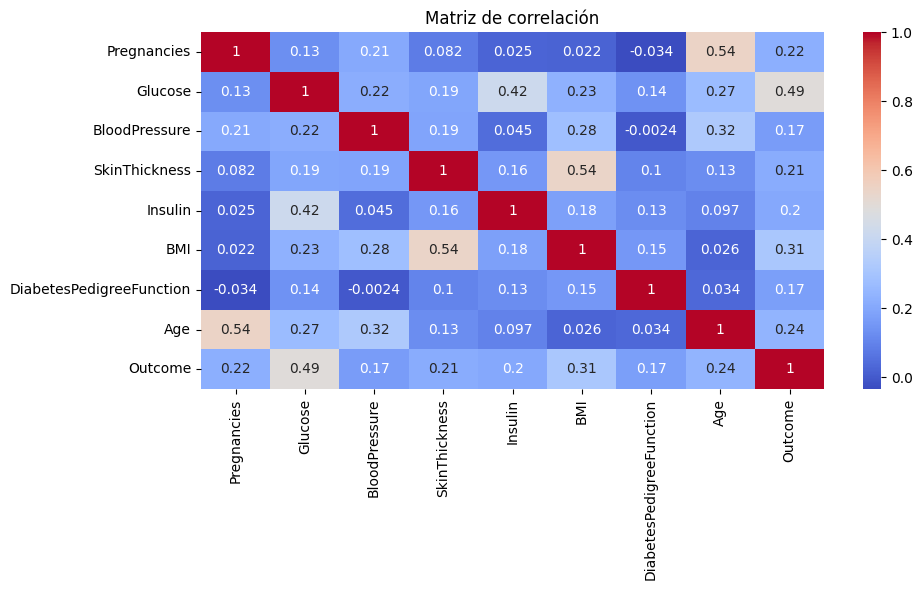


Correlación con Outcome:
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_clean.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Ver correlación con Outcome
print("\nCorrelación con Outcome:")
print(corr["Outcome"].sort_values(ascending=False))

## 4. División del Dataset y Normalización

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalización (necesaria para SVM y KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 614 muestras
Prueba:        154 muestras


## 5. Modelo 1 – Random Forest

=== Random Forest ===
Accuracy: 0.7468

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



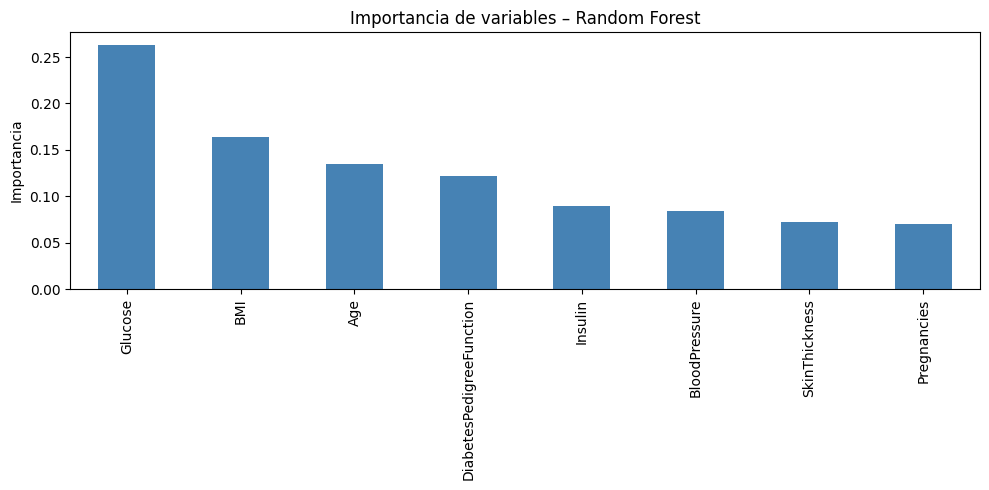

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"=== Random Forest ===")
print(f"Accuracy: {rf_acc:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, rf_pred))

# Importancia de variables
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
importances.plot(kind="bar", figsize=(10, 5), color="steelblue")
plt.title("Importancia de variables – Random Forest")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

## 6. Modelo 2 – SVM (Support Vector Machine)

=== SVM (kernel RBF) ===
Accuracy: 0.7468

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        99
           1       0.67      0.58      0.62        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



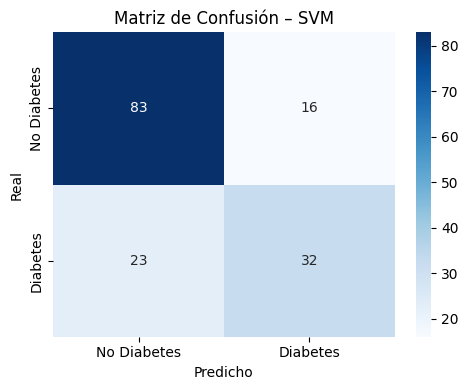

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc  = accuracy_score(y_test, svm_pred)

print(f"=== SVM (kernel RBF) ===")
print(f"Accuracy: {svm_acc:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, svm_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Matriz de Confusión – SVM")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

## 7. Modelo 3 – KNN (K-Nearest Neighbors)

Mejor k: 12 con accuracy: 0.7922


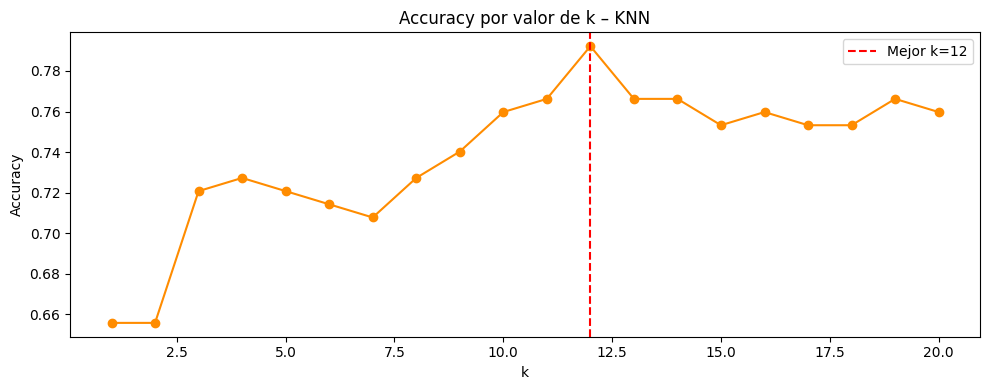


=== KNN (k=12) ===
Accuracy: 0.7922

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.74      0.64      0.69        55

    accuracy                           0.79       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Buscar el mejor k entre 1 y 20
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    k_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = k_scores.index(max(k_scores)) + 1
print(f"Mejor k: {best_k} con accuracy: {max(k_scores):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(range(1, 21), k_scores, marker="o", color="darkorange")
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Mejor k={best_k}")
plt.title("Accuracy por valor de k – KNN")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_acc  = accuracy_score(y_test, knn_pred)

print(f"\n=== KNN (k={best_k}) ===")
print(f"Accuracy: {knn_acc:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, knn_pred))

## 8. Modelo 4 – Árbol de Decisión

=== Árbol de Decisión (max_depth=5) ===
Accuracy: 0.7273

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        99
           1       0.59      0.76      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.73       154



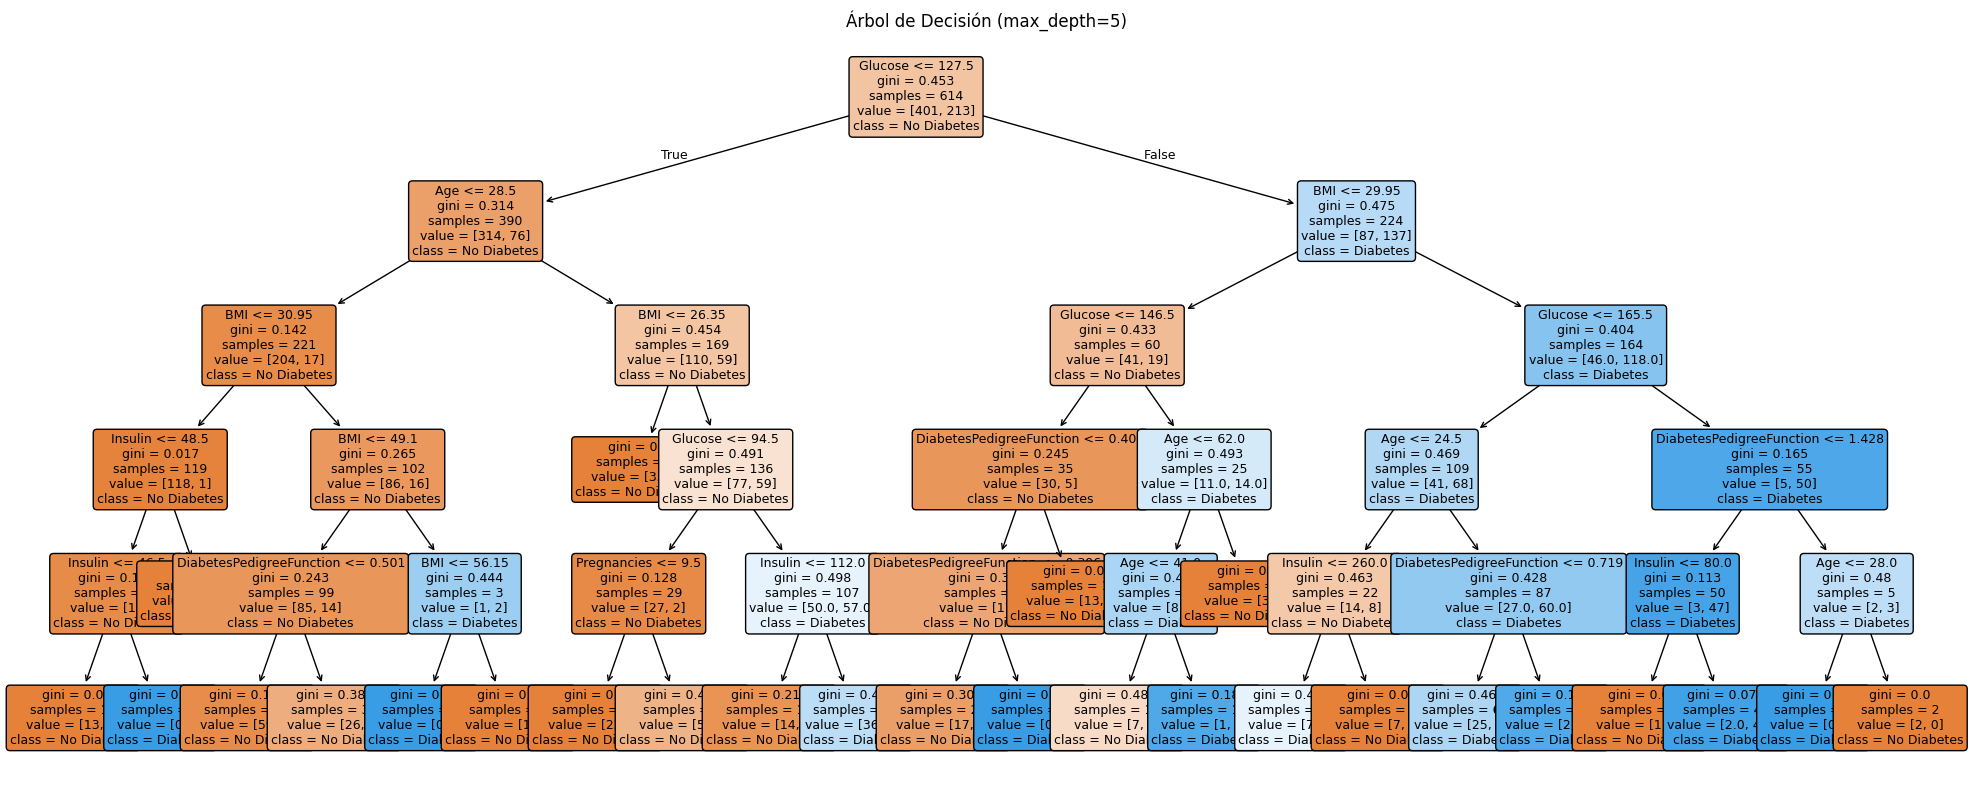

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print(f"=== Árbol de Decisión (max_depth=5) ===")
print(f"Accuracy: {dt_acc:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, dt_pred))

# Visualizar el árbol
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=X.columns.tolist(),
          class_names=["No Diabetes", "Diabetes"],
          filled=True, rounded=True, fontsize=9)
plt.title("Árbol de Decisión (max_depth=5)")
plt.tight_layout()
plt.show()

## 9. Comparación de Modelos

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

resultados = pd.DataFrame({
    "Modelo": ["Random Forest", "SVM", f"KNN (k={best_k})", "Árbol de Decisión"],
    "Accuracy": [
        rf_acc,
        svm_acc,
        knn_acc,
        dt_acc
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1-Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred)
    ]
})

resultados = resultados.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("=== Tabla comparativa ===")
print(resultados.to_string(index=False, float_format="{:.4f}".format))

=== Tabla comparativa ===
           Modelo  Accuracy  Precision  Recall  F1-Score
       KNN (k=12)    0.7922     0.7447  0.6364    0.6863
    Random Forest    0.7468     0.6379  0.6727    0.6549
              SVM    0.7468     0.6667  0.5818    0.6214
Árbol de Decisión    0.7273     0.5915  0.7636    0.6667


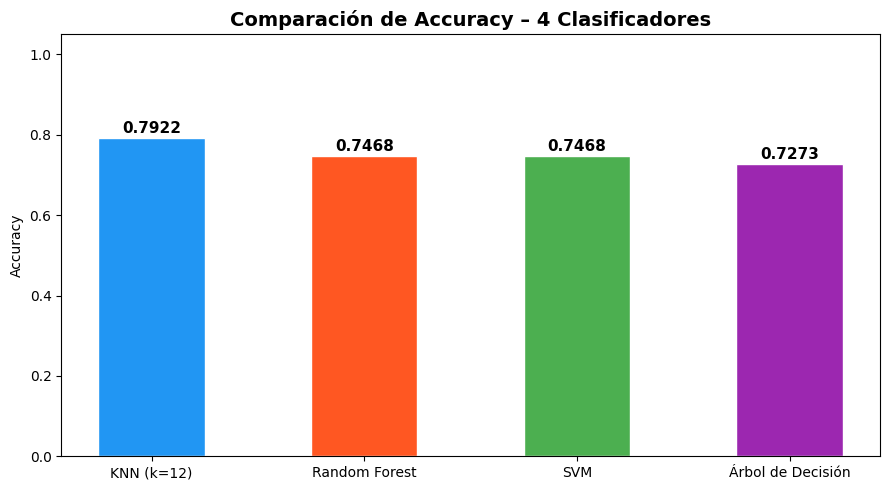

Gráfica guardada como comparacion_accuracy.png


In [ ]:
# Gráfica de barras – Accuracy
colores = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0"]

plt.figure(figsize=(9, 5))
bars = plt.bar(resultados["Modelo"], resultados["Accuracy"], color=colores, edgecolor="white", width=0.5)

for bar, val in zip(bars, resultados["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.4f}",
             ha="center", va="bottom", fontweight="bold", fontsize=11)

plt.ylim(0, 1.05)
plt.title("Comparación de Accuracy – 4 Clasificadores", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("comparacion_accuracy.png", dpi=150)
plt.show()
print("Gráfica guardada como comparacion_accuracy.png")

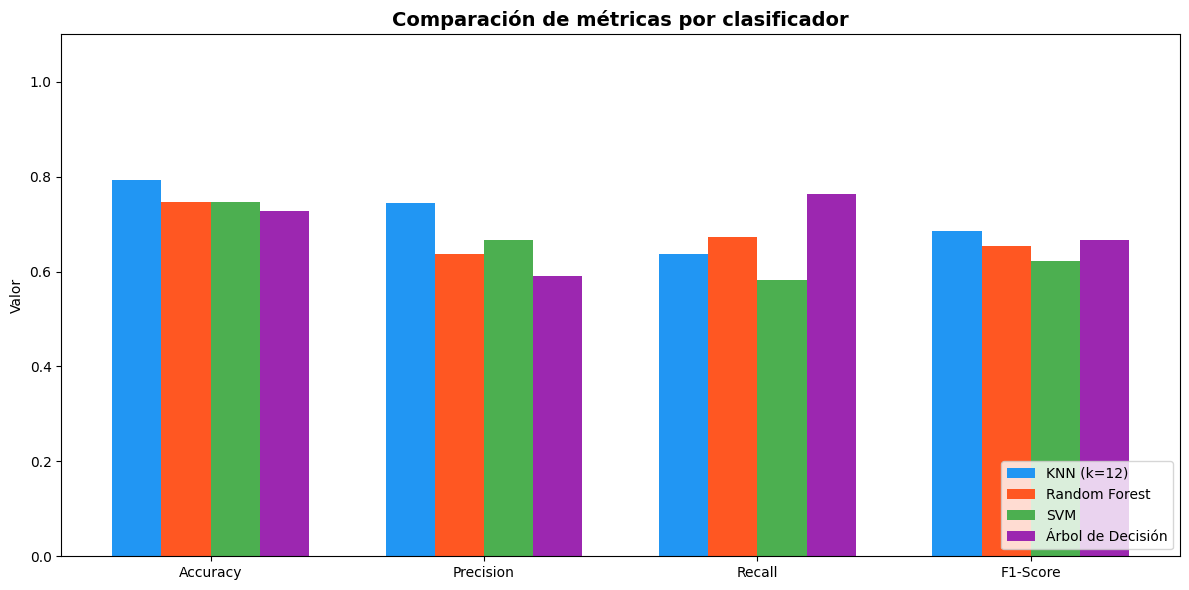

In [ ]:
# Gráfica de radar / métricas múltiples
metricas = ["Accuracy", "Precision", "Recall", "F1-Score"]
modelos  = resultados["Modelo"].tolist()

x = np.arange(len(metricas))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
for i, (modelo, color) in enumerate(zip(modelos, colores)):
    vals = resultados[resultados["Modelo"] == modelo][metricas].values.flatten()
    ax.bar(x + i * width, vals, width, label=modelo, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor")
ax.set_title("Comparación de métricas por clasificador", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Conclusiones

| Modelo | Fortaleza | Debilidad |
|--------|-----------|----------|
| **Random Forest** | Alta accuracy, robusto a outliers, no requiere normalización | Menos interpretable |
| **SVM** | Buen rendimiento en espacios de alta dimensión | Sensible a la escala, costoso en datasets grandes |
| **KNN** | Simple, no paramétrico | Lento en predicción, sensible a datos ruidosos |
| **Árbol de Decisión** | Muy interpretable, visualizable | Propenso a overfitting sin poda |

> El modelo con mayor accuracy en este experimento fue el señalado en la tabla de resultados. Para un problema médico como detección de diabetes, además del accuracy conviene observar el **Recall** (sensibilidad), ya que los falsos negativos (no detectar diabetes real) son más costosos que los falsos positivos.